# Time-Series Wrap-Up

최종 메시지는 **final MSE/MAE 비교**이며, 수렴 곡선과 imitation dynamics는 보조 해석으로 둡니다.

공식 입력 소스:
- `results/paper_rerun_canonical/time_series/time_series`


In [1]:
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / ".git").exists() and (candidate / "notebook").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
NOTEBOOK_ROOT = REPO_ROOT / "notebook" / "FINAL_WRAPUP"
if str(NOTEBOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from _shared.io import load_curve_file, load_epoch_metrics, load_pks_results, load_run_tree
from _shared.plotting import (
    DATASET_ORDER,
    METHOD_COLORS,
    METHOD_ORDER,
    apply_report_style,
    pretty_dataset,
    pretty_method,
    pretty_model,
    pretty_pair,
    save_figure,
    save_table,
)

apply_report_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

NOTEBOOK_ROOT


PosixPath('/home/namkyeong/ssmo/notebook/FINAL_WRAPUP')

## Load


In [2]:
TIME_SERIES_ROOT = REPO_ROOT / "results" / "paper_rerun_canonical" / "time_series" / "time_series"
time_runs = load_run_tree(TIME_SERIES_ROOT)
if len(time_runs) != 36:
    raise AssertionError(f"Expected 36 time-series runs, found {len(time_runs)}")

expected_datasets = {"etth1", "electricity", "weather"}
observed_datasets = set(time_runs["dataset"].unique())
if observed_datasets != expected_datasets:
    raise AssertionError(f"Unexpected time-series dataset set: {observed_datasets}")

display(time_runs.head())
time_runs[["dataset", "model", "peer_model", "method", "loss_name"]].drop_duplicates().sort_values(
    ["dataset", "model", "peer_model", "method"]
)


,task,dataset,method,model,peer_model,pair_tag,pair_type,is_joint_training,is_heterogeneous_pair,mean_imitation_weight,active_imitation_ratio,supervised_loss_mean,imitation_loss_mean,curve_mode,model_idx,model1,model2,regression_imitation_loss,lambda_imitation,margin,warmup_epochs,epochs,seed,epoch_log_path,best_val_mse,final_val_mse,final_val_mae,best_metric,best_metric_key,final_metric,best_metric1,final_metric1,best_val_mse1,final_val_mse1,final_val_mae1,final_val1,num_parameters,num_parameters1,meta,loss_name,curve_path,epoch_metrics_path,summary_path,best_metric2,final_metric2,best_val_mse2,final_val_mse2,final_val_mae2,final_val2,num_parameters2
0,time_series,electricity,independent,dlinear,None,dlinear,single,False,False,0.0,0.0,0.166367,0.000000,single,1,dlinear,None,mse,1.0,0.0,3,60,0,results/paper_rerun_canonical/time_series/time...,0.152431,0.153076,0.235069,0.152431,mse,0.153076,0.152431,0.153076,0.152431,0.153076,0.235069,0.153076,2328,2328,"{'dataset': 'electricity', 'num_features': 321...",mse,/home/namkyeong/ssmo/results/paper_rerun_canon...,/home/namkyeong/ssmo/results/paper_rerun_canon...,/home/namkyeong/ssmo/results/paper_rerun_canon...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,time_series,electricity,independent,dlinear,None,dlinear,single,False,False,0.0,0.0,0.166389,0.000000,single,1,dlinear,None,mse,1.0,0.0,3,60,1,results/paper_rerun_canonical/time_series/time...,0.152357,0.152644,0.234486,0.152357,mse,0.152644,0.152357,0.152644,0.152357,0.152644,0.234486,0.152644,2328,2328,"{'dataset': 'electricity', 'num_features': 321...",mse,/home/namkyeong/ssmo/results/paper_rerun_canon...,/home/namkyeong/ssmo/results/paper_rerun_canon...,/home/namkyeong/ssmo/results/paper_rerun_canon...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,time_series,electricity,independent,dlinear,None,dlinear,single,False,False,0.0,0.0,0.166489,0.000000,single,1,dlinear,None,mse,1.0,0.0,3,60,2,results/paper_rerun_canonical/time_series/time...,0.152441,0.152660,0.234619,0.152441,mse,0.152660,0.152441,0.152660,0.152441,0.152660,0.234619,0.152660,2328,2328,"{'dataset': 'electricity', 'num_features': 321...",mse,/home/namkyeong/ssmo/results/paper_rerun_canon...,/home/namkyeong/ssmo/results/paper_rerun_canon...,/home/namkyeong/ssmo/results/paper_rerun_canon...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,time_series,electricity,dml,transformer,dlinear,transformer__dlinear,heterogeneous,True,True,1.0,1.0,0.114746,0.054072,pair,1,transformer,dlinear,mse,1.0,0.0,3,60,0,results/paper_rerun_canonical/time_series/time...,0.169030,0.175879,0.292814,0.169030,mse,0.175879,0.169030,0.175879,0.169030,0.175879,0.292814,0.175879,1431576,1431576,"{'dataset': 'electricity', 'num_features': 321...",mse,/home/namkyeong/ssmo/results/paper_rerun_canon...,/home/namkyeong/ssmo/results/paper_rerun_canon...,/home/namkyeong/ssmo/results/paper_rerun_canon...,0.153682,0.153682,0.153682,0.153682,0.238369,0.153682,2328.0
4,time_series,electricity,dml,transformer,dlinear,transformer__dlinear,heterogeneous,True,True,1.0,1.0,0.114830,0.053946,pair,1,transformer,dlinear,mse,1.0,0.0,3,60,1,results/paper_rerun_canonical/time_series/time...,0.170110,0.173136,0.291183,0.170110,mse,0.173136,0.170110,0.173136,0.170110,0.173136,0.291183,0.173136,1431576,1431576,"{'dataset': 'electricity', 'num_features': 321...",mse,/home/namkyeong/ssmo/results/paper_rerun_canon...,/home/namkyeong/ssmo/results/paper_rerun_canon...,/home/namkyeong/ssmo/results/paper_rerun_canon...,0.153765,0.154505,0.153765,0.154505,0.241864,0.154505,2328.0


,dataset,model,peer_model,method,loss_name
0,electricity,dlinear,None,independent,mse
3,electricity,transformer,dlinear,dml,mse
6,electricity,transformer,dlinear,ssml,mse
9,electricity,transformer,None,independent,mse
12,etth1,dlinear,None,independent,mse
15,etth1,transformer,dlinear,dml,mse
18,etth1,transformer,dlinear,ssml,mse
21,etth1,transformer,None,independent,mse
24,weather,dlinear,None,independent,mse
27,weather,transformer,dlinear,dml,mse


## Normalize


In [3]:
def stack_curves(curves):
    prepared = []
    for curve in curves:
        if curve is None:
            continue
        arr = np.asarray(curve, dtype=float).reshape(-1)
        if arr.size:
            prepared.append(arr)
    if not prepared:
        raise ValueError("No non-empty curves were provided.")
    min_len = min(len(arr) for arr in prepared)
    return np.vstack([arr[:min_len] for arr in prepared])

def mean_and_std(curves):
    stacked = stack_curves(curves)
    return stacked.mean(axis=0), stacked.std(axis=0)


def pair_category(row):
    peer = row["peer_model"]
    if pd.isna(peer) or peer is None:
        return "single"
    if peer == row["model"]:
        return "homogeneous"
    return "heterogeneous"

time_runs = time_runs.copy()
time_runs["pair_category"] = time_runs.apply(pair_category, axis=1)
time_runs["dataset_label"] = time_runs["dataset"].map(pretty_dataset)
time_runs["model_label"] = time_runs["model"].map(pretty_model)
time_runs["peer_label"] = time_runs["peer_model"].map(pretty_model)
time_runs["method_label"] = time_runs["method"].map(pretty_method)

def config_label(row):
    if row["pair_category"] == "single":
        return f"{pretty_model(row['model'])} (single)"
    return f"{pretty_model(row['model'])} | peer={pretty_model(row['peer_model'])}"

time_runs["config_label"] = time_runs.apply(config_label, axis=1)
time_runs["dataset_order"] = time_runs["dataset"].map(DATASET_ORDER)
time_runs["method_order"] = time_runs["method"].map(METHOD_ORDER)
time_runs["pair_order"] = time_runs["pair_category"].map({"single": 0, "homogeneous": 1, "heterogeneous": 2})

summary_columns = [
    "dataset",
    "pair_category",
    "model",
    "peer_model",
    "method",
    "final_metric",
    "best_metric",
    "final_val_mae",
    "mean_imitation_weight",
    "active_imitation_ratio",
]
display(
    time_runs
    .sort_values(["dataset_order", "pair_order", "model", "peer_model", "method_order"])[summary_columns]
    .reset_index(drop=True)
)


,dataset,pair_category,model,peer_model,method,final_metric,best_metric,final_val_mae,mean_imitation_weight,active_imitation_ratio
0,etth1,single,dlinear,None,independent,0.273053,0.271790,0.341358,0.000000,0.000000
1,etth1,single,dlinear,None,independent,0.276377,0.272238,0.343590,0.000000,0.000000
2,etth1,single,dlinear,None,independent,0.276522,0.272204,0.345505,0.000000,0.000000
3,etth1,single,transformer,None,independent,0.406374,0.312892,0.449718,0.000000,0.000000
4,etth1,single,transformer,None,independent,0.408043,0.305302,0.459641,0.000000,0.000000
5,etth1,single,transformer,None,independent,0.388237,0.324131,0.432994,0.000000,0.000000
6,etth1,heterogeneous,transformer,dlinear,dml,0.317268,0.281163,0.389586,1.000000,1.000000
7,etth1,heterogeneous,transformer,dlinear,dml,0.324649,0.291373,0.391668,1.000000,1.000000
8,etth1,heterogeneous,transformer,dlinear,dml,0.310668,0.292789,0.385108,1.000000,1.000000
9,etth1,heterogeneous,transformer,dlinear,ssml,0.357577,0.301476,0.408997,0.077128,0.077128


## Summary Table


In [4]:
time_summary = (
    time_runs[
        [
            "dataset",
            "dataset_label",
            "pair_category",
            "config_label",
            "method",
            "method_label",
            "final_metric",
            "best_metric",
            "final_val_mae",
            "mean_imitation_weight",
            "active_imitation_ratio",
        ]
    ]
    .sort_values(["dataset", "pair_category", "config_label", "method"])
    .reset_index(drop=True)
)

display(time_summary)
raw_export_path = save_table(time_summary, "time_series", "time_series_summary")
display(Markdown(f"Saved summary table to `{raw_export_path}`."))


,dataset,dataset_label,pair_category,config_label,method,method_label,final_metric,best_metric,final_val_mae,mean_imitation_weight,active_imitation_ratio
0,electricity,Electricity,heterogeneous,Transformer | peer=DLinear,dml,DML,0.175879,0.169030,0.292814,1.000000,1.000000
1,electricity,Electricity,heterogeneous,Transformer | peer=DLinear,dml,DML,0.173136,0.170110,0.291183,1.000000,1.000000
2,electricity,Electricity,heterogeneous,Transformer | peer=DLinear,dml,DML,0.174229,0.171130,0.292131,1.000000,1.000000
3,electricity,Electricity,heterogeneous,Transformer | peer=DLinear,ssml,SSML,0.166480,0.161590,0.283041,0.125421,0.125421
4,electricity,Electricity,heterogeneous,Transformer | peer=DLinear,ssml,SSML,0.167530,0.163452,0.284606,0.126119,0.126119
5,electricity,Electricity,heterogeneous,Transformer | peer=DLinear,ssml,SSML,0.169301,0.163556,0.285470,0.125789,0.125789
6,electricity,Electricity,single,DLinear (single),independent,Independent,0.153076,0.152431,0.235069,0.000000,0.000000
7,electricity,Electricity,single,DLinear (single),independent,Independent,0.152644,0.152357,0.234486,0.000000,0.000000
8,electricity,Electricity,single,DLinear (single),independent,Independent,0.152660,0.152441,0.234619,0.000000,0.000000
9,electricity,Electricity,single,Transformer (single),independent,Independent,0.172328,0.167229,0.288451,0.000000,0.000000


Saved summary table to `/home/namkyeong/ssmo/notebook/FINAL_WRAPUP/tables/time_series/time_series_summary.csv`.

## Main Figures


Saved main figure to `/home/namkyeong/ssmo/notebook/FINAL_WRAPUP/figures/time_series/time_series_final_mse.png`.

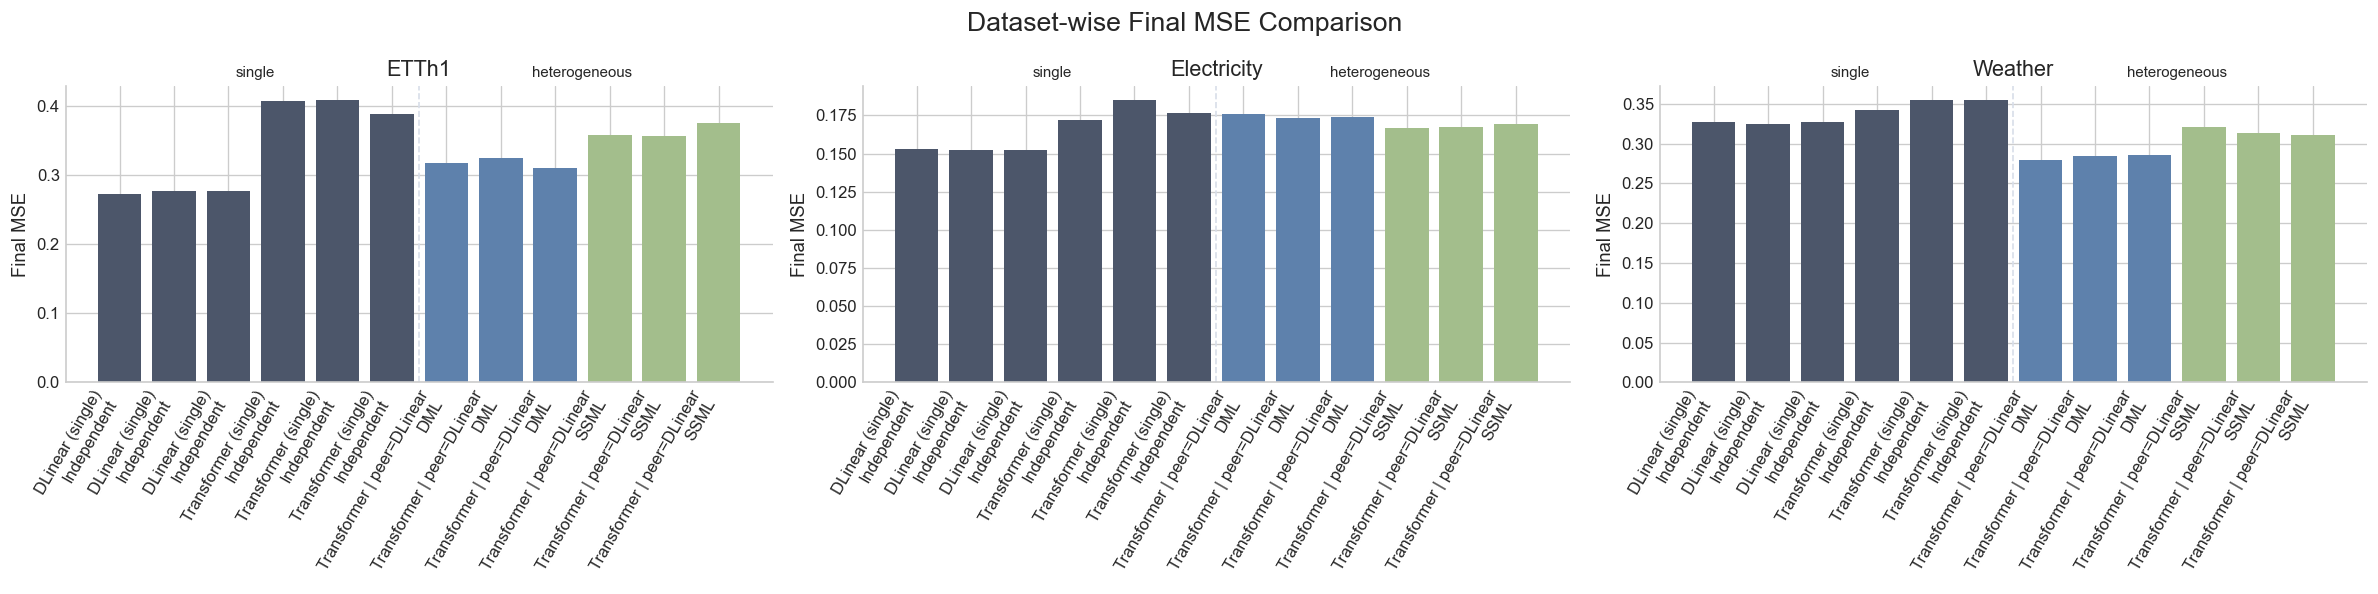

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
axes = np.atleast_1d(axes)

for ax, dataset in zip(axes, sorted(time_runs["dataset"].unique(), key=lambda x: DATASET_ORDER.get(x, 99))):
    ds = (
        time_runs[time_runs["dataset"] == dataset]
        .sort_values(["pair_order", "model", "peer_model", "method_order"])
        .reset_index(drop=True)
    )
    x = np.arange(len(ds))
    colors = [METHOD_COLORS.get(method, "#4c566a") for method in ds["method"]]
    ax.bar(x, ds["final_metric"], color=colors)
    ax.set_title(pretty_dataset(dataset))
    ax.set_ylabel("Final MSE")
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{label}\n{method}" for label, method in zip(ds["config_label"], ds["method_label"])],
        rotation=60,
        ha="right",
    )

    categories = ds["pair_category"].tolist()
    for idx in range(1, len(categories)):
        if categories[idx] != categories[idx - 1]:
            ax.axvline(idx - 0.5, color="#d8dee9", linestyle="--", linewidth=1.0)

    category_positions = ds.groupby("pair_category").agg(start=("pair_order", "min"), count=("pair_order", "size"))
    for category, cat_df in ds.groupby("pair_category"):
        start = cat_df.index.min()
        stop = cat_df.index.max()
        midpoint = (start + stop) / 2.0
        ax.text(midpoint, ax.get_ylim()[1] * 1.02, category, ha="center", va="bottom", fontsize=9)

fig.suptitle("Dataset-wise Final MSE Comparison", fontsize=16)
fig.tight_layout()
main_path = save_figure(fig, "time_series", "time_series_final_mse")
display(Markdown(f"Saved main figure to `{main_path}`."))
plt.show()


## Secondary Figures


Saved MAE figure to `/home/namkyeong/ssmo/notebook/FINAL_WRAPUP/figures/time_series/time_series_final_mae.png`.

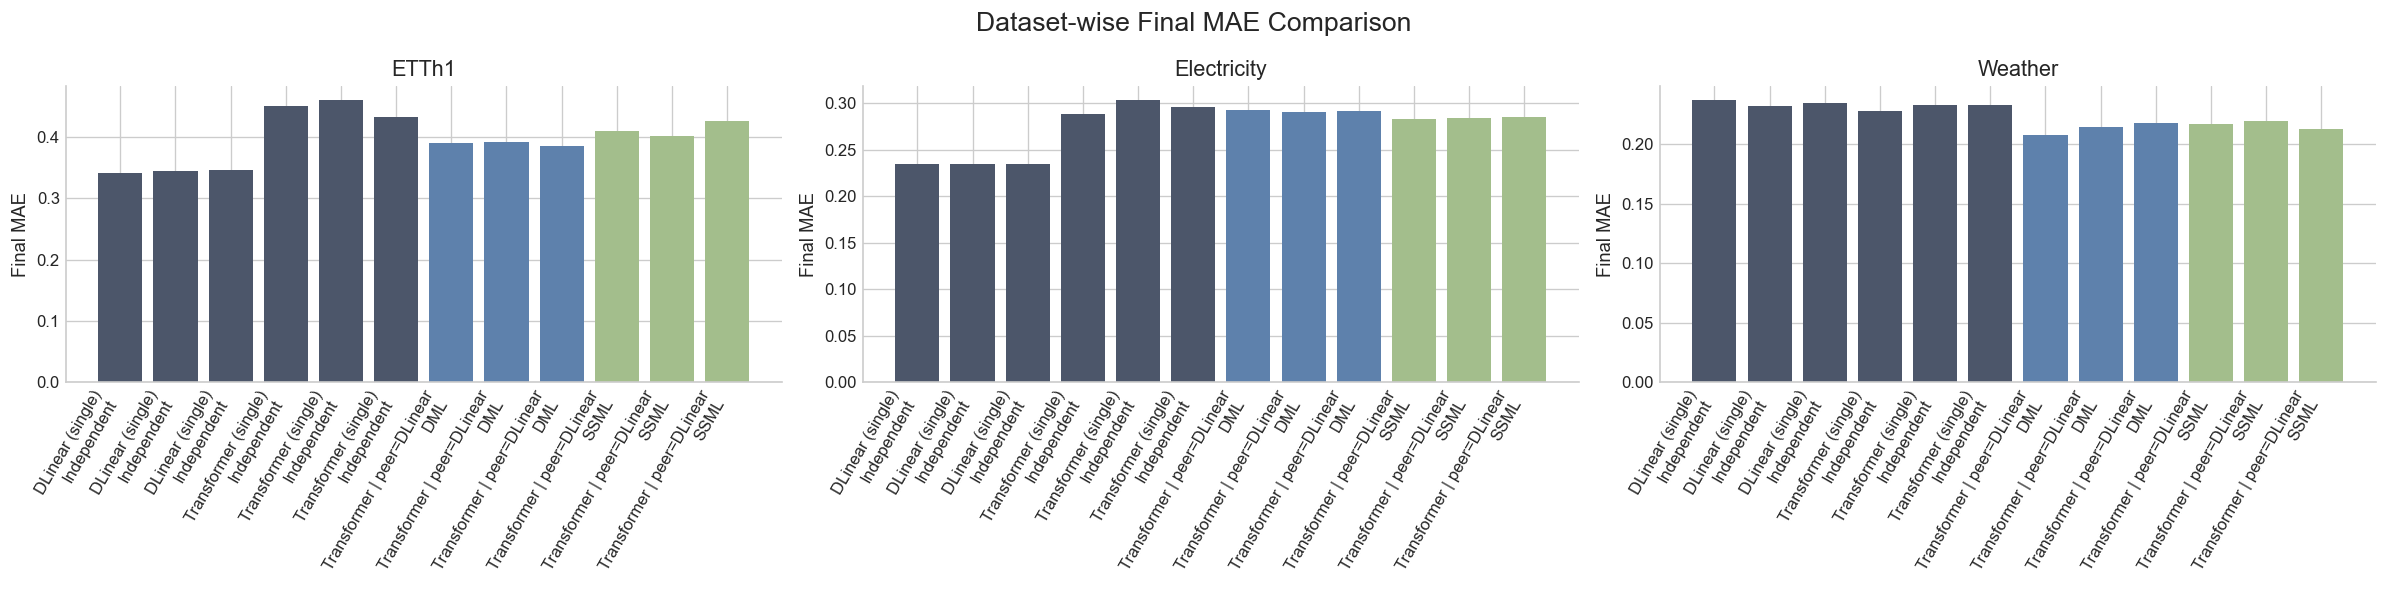

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=False)
axes = np.atleast_1d(axes)

for ax, dataset in zip(axes, sorted(time_runs["dataset"].unique(), key=lambda x: DATASET_ORDER.get(x, 99))):
    ds = (
        time_runs[time_runs["dataset"] == dataset]
        .sort_values(["pair_order", "model", "peer_model", "method_order"])
        .reset_index(drop=True)
    )
    x = np.arange(len(ds))
    colors = [METHOD_COLORS.get(method, "#4c566a") for method in ds["method"]]
    ax.bar(x, ds["final_val_mae"], color=colors)
    ax.set_title(pretty_dataset(dataset))
    ax.set_ylabel("Final MAE")
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{label}\n{method}" for label, method in zip(ds["config_label"], ds["method_label"])],
        rotation=60,
        ha="right",
    )

fig.suptitle("Dataset-wise Final MAE Comparison", fontsize=16)
fig.tight_layout()
mae_path = save_figure(fig, "time_series", "time_series_final_mae")
display(Markdown(f"Saved MAE figure to `{mae_path}`."))
plt.show()


Saved representative curve figure to `/home/namkyeong/ssmo/notebook/FINAL_WRAPUP/figures/time_series/time_series_representative_val_mse_curves.png`.

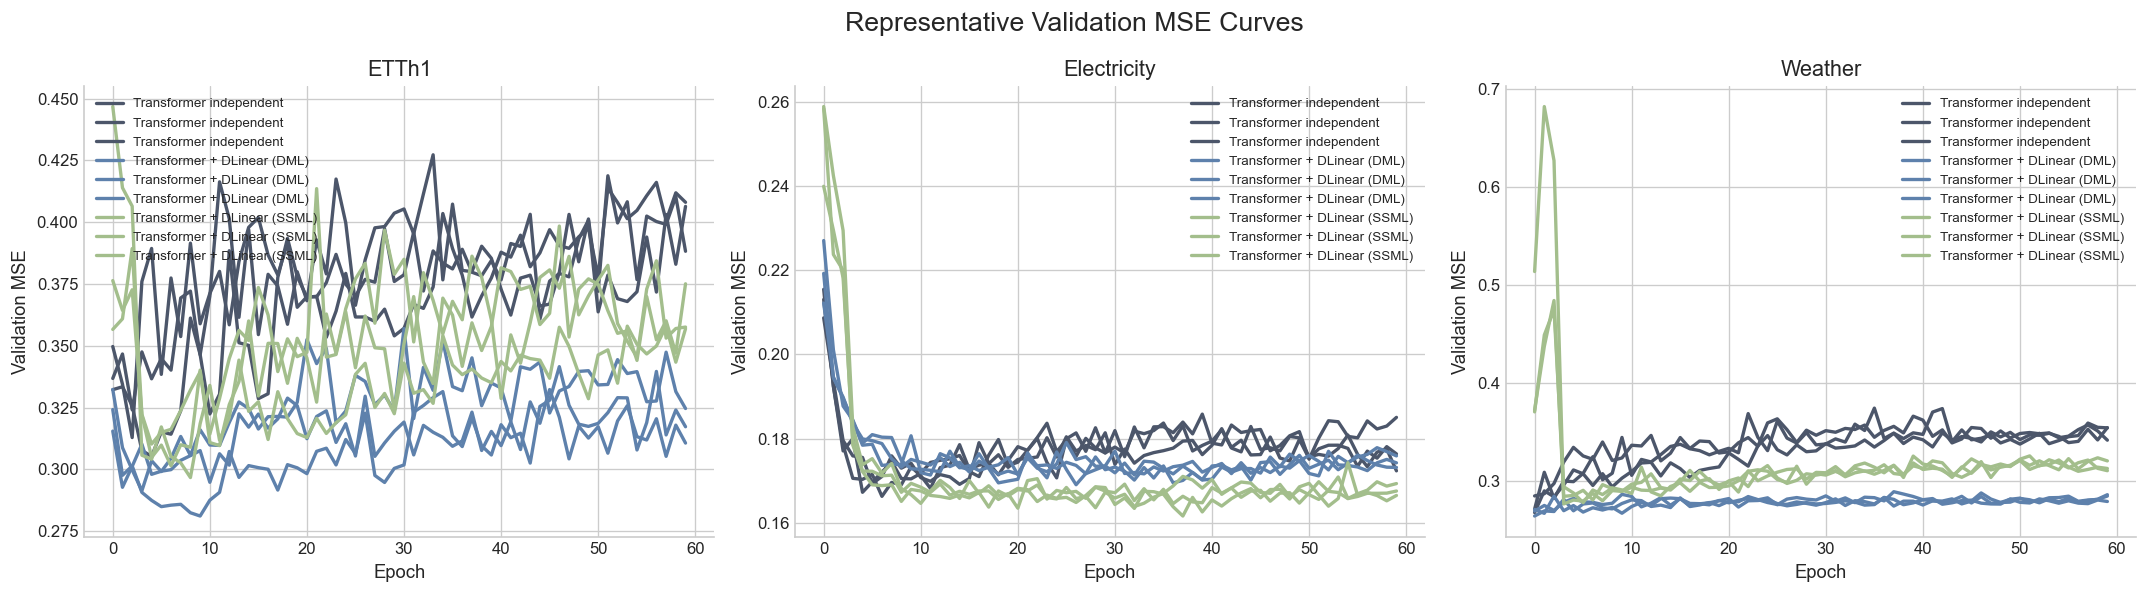

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
axes = np.atleast_1d(axes)

for ax, dataset in zip(axes, sorted(time_runs["dataset"].unique(), key=lambda x: DATASET_ORDER.get(x, 99))):
    subset = time_runs[
        (time_runs["dataset"] == dataset)
        & (
            ((time_runs["model"] == "transformer") & (time_runs["peer_model"] == "dlinear"))
            | ((time_runs["model"] == "transformer") & (time_runs["method"] == "independent"))
        )
    ].copy()
    subset["curve_label"] = subset.apply(
        lambda row: "Transformer independent"
        if row["method"] == "independent"
        else f"Transformer + DLinear ({pretty_method(row['method'])})",
        axis=1,
    )

    for _, row in subset.sort_values(["method_order"]).iterrows():
        curves = load_curve_file(row["curve_path"])
        ax.plot(
            curves["val_mse"],
            label=row["curve_label"],
            color=METHOD_COLORS.get(row["method"], "#4c566a"),
            linewidth=2.0,
        )

    ax.set_title(pretty_dataset(dataset))
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation MSE")
    ax.legend(fontsize=8)

fig.suptitle("Representative Validation MSE Curves", fontsize=16)
fig.tight_layout()
curve_path = save_figure(fig, "time_series", "time_series_representative_val_mse_curves")
display(Markdown(f"Saved representative curve figure to `{curve_path}`."))
plt.show()


Saved dynamics figure to `/home/namkyeong/ssmo/notebook/FINAL_WRAPUP/figures/time_series/time_series_heterogeneous_dynamics.png`.

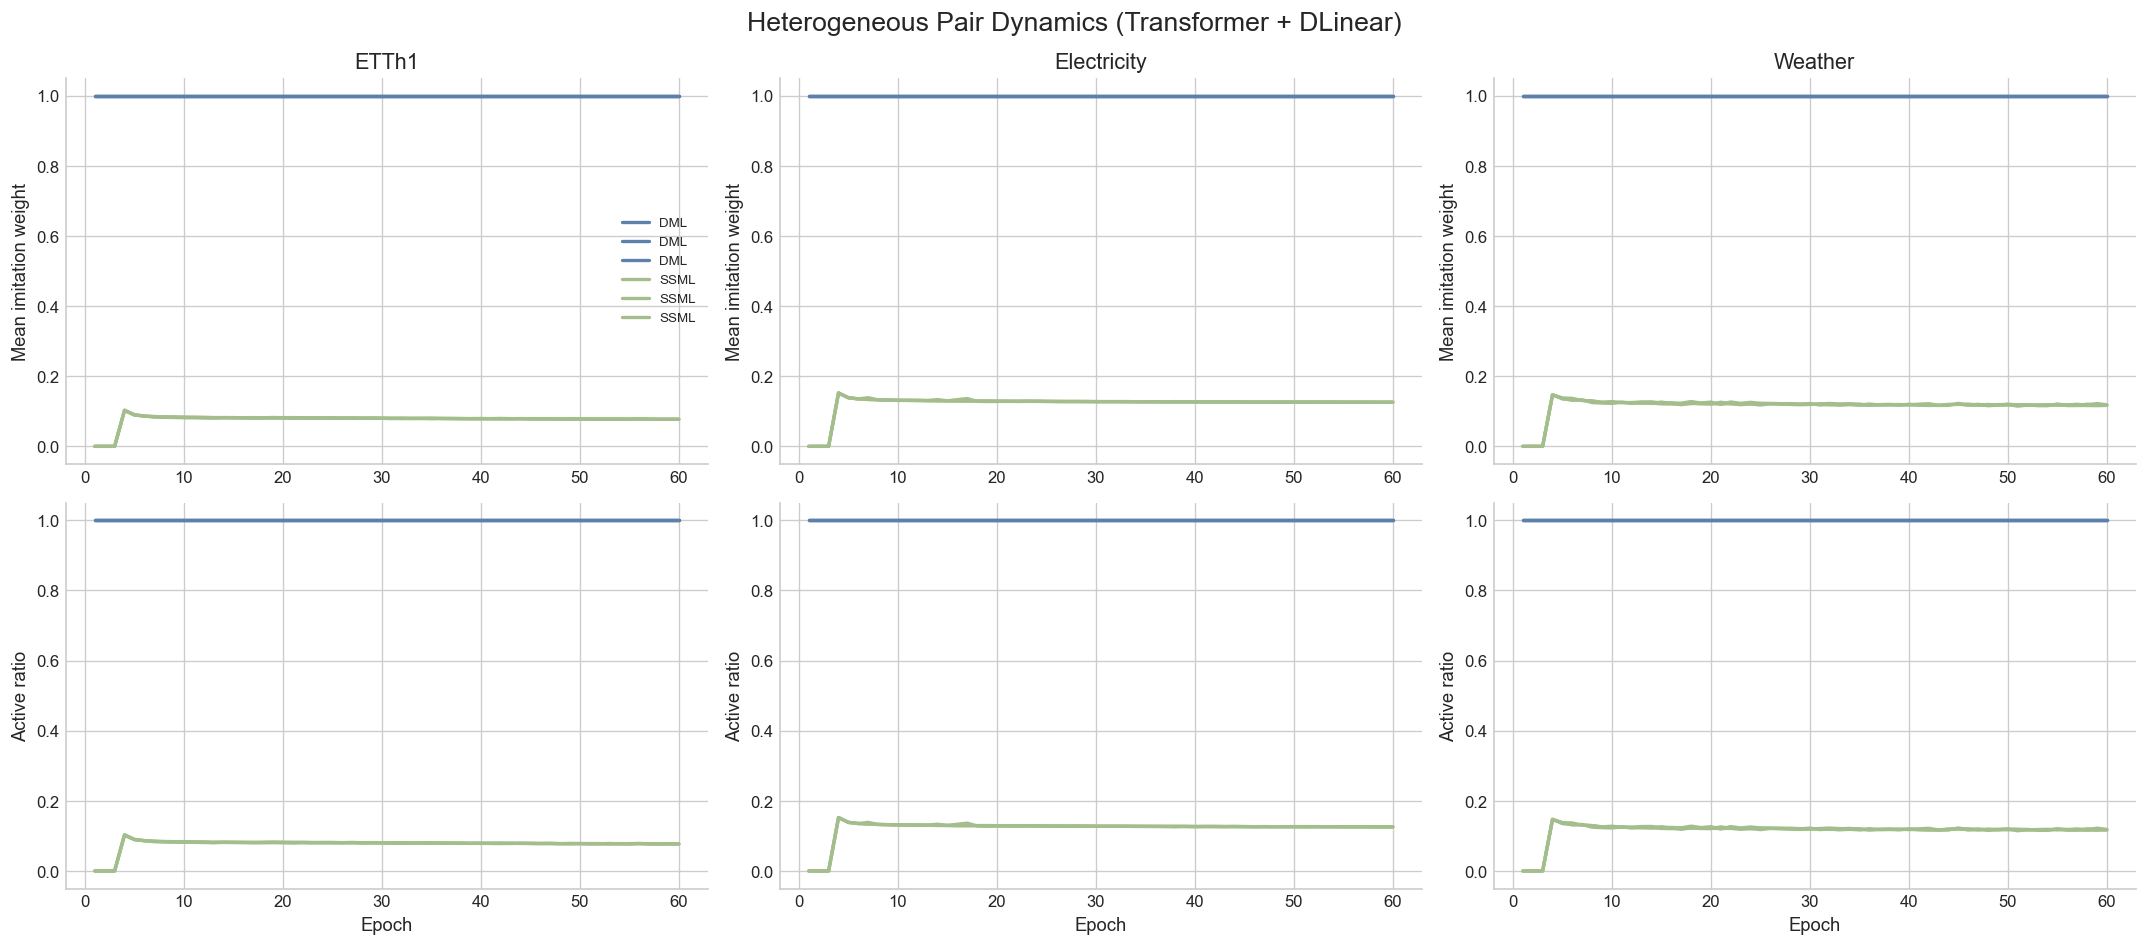

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False)

for col, dataset in enumerate(sorted(time_runs["dataset"].unique(), key=lambda x: DATASET_ORDER.get(x, 99))):
    subset = time_runs[
        (time_runs["dataset"] == dataset)
        & (time_runs["model"] == "transformer")
        & (time_runs["peer_model"] == "dlinear")
    ].copy()

    top_ax = axes[0, col]
    bottom_ax = axes[1, col]

    for _, row in subset.sort_values(["method_order"]).iterrows():
        metrics = load_epoch_metrics(row["epoch_metrics_path"])
        top_ax.plot(
            metrics["epoch"],
            metrics["mean_imitation_weight"],
            label=pretty_method(row["method"]),
            color=METHOD_COLORS.get(row["method"], "#4c566a"),
            linewidth=2.0,
        )
        bottom_ax.plot(
            metrics["epoch"],
            metrics["active_imitation_ratio"],
            label=pretty_method(row["method"]),
            color=METHOD_COLORS.get(row["method"], "#4c566a"),
            linewidth=2.0,
        )

    top_ax.set_title(pretty_dataset(dataset))
    top_ax.set_ylabel("Mean imitation weight")
    bottom_ax.set_xlabel("Epoch")
    bottom_ax.set_ylabel("Active ratio")

axes[0, 0].legend(fontsize=8)
fig.suptitle("Heterogeneous Pair Dynamics (Transformer + DLinear)", fontsize=16)
fig.tight_layout()
dynamics_path = save_figure(fig, "time_series", "time_series_heterogeneous_dynamics")
display(Markdown(f"Saved dynamics figure to `{dynamics_path}`."))
plt.show()


## Export


In [9]:
export_frame = time_runs.drop(
    columns=["summary_path", "curve_path", "epoch_metrics_path", "epoch_log_path"],
    errors="ignore",
).copy()
export_path = save_table(export_frame, "time_series", "time_series_runs")
display(Markdown(f"Saved normalized run table to `{export_path}`."))


Saved normalized run table to `/home/namkyeong/ssmo/notebook/FINAL_WRAPUP/tables/time_series/time_series_runs.csv`.

## Notes

- 현재 결과는 single-seed wrap-up이라 표준편차 해석은 하지 않습니다.
- `heterogeneous`는 `Transformer + DLinear`, `homogeneous`는 동일 아키텍처 peer 조합입니다.
- 메인 메시지는 final metric이지만, 마지막 figure에서 imitation weight와 active ratio 변화도 함께 남깁니다.
